In [70]:
import numpy as np
import matplotlib.pyplot as plt

# Problema 1A

In [71]:
f = lambda x: np.cos(x) - x
g = lambda x: np.cos(x)
x0 = 1

In [72]:
def punto_fijo(g,x0,tol=1e-6,maxit=100, verbose=True):

    x_prev = x0
    x = x0
    k = 0
    error = None

    if verbose:
        print("k\t\txk\t\terror")

    while k < maxit:

        x = g(x_prev)
        error = np.abs(x - x_prev)

        if verbose:
            print(f"{k}\t\t{x}\t\t{error}")

        if error < tol:
            break

        x_prev = x
        k += 1

    return x

In [73]:
punto_fijo(g,x0)

k		xk		error
0		0.5403023058681398		0.45969769413186023
1		0.8575532158463934		0.31725090997825367
2		0.6542897904977791		0.2032634253486143
3		0.7934803587425656		0.13919056824478648
4		0.7013687736227565		0.0921115851198091
5		0.7639596829006542		0.06259090927789768
6		0.7221024250267077		0.04185725787394645
7		0.7504177617637605		0.028315336737052776
8		0.7314040424225098		0.019013719341250734
9		0.7442373549005569		0.012833312478047088
10		0.7356047404363474		0.008632614464209487
11		0.7414250866101092		0.0058203461737618145
12		0.7375068905132428		0.003918196096866389
13		0.7401473355678757		0.0026404450546329006
14		0.7383692041223232		0.0017781314455525
15		0.7395672022122561		0.0011979980899329279
16		0.7387603198742113		0.0008068823380448231
17		0.7393038923969059		0.0005435725226945465
18		0.7389377567153445		0.0003661356815614081
19		0.7391843997714936		0.00024664305614918725
20		0.7390182624274122		0.00016613734408144065
21		0.7391301765296711		0.00011191410225885878
22		0.

np.float64(0.7390855263619245)

# Problema 1B

In [74]:
def punto_fijo_divergencia(g,x0,tol=1e-6,maxit=100, verbose=True):

    x_prev = x0
    x = x0
    k = 0
    error_prev = None
    error = None

    if verbose:
        print("k\t\txk\t\terror")

    while k < maxit:

        x = g(x_prev)
        error = np.abs(x - x_prev)

        if verbose:
            print(f"{k}\t\t{x}\t\t{error}")

        if error_prev is not None and error_prev > error:
            print("Hay Divergencia")

        if error < tol:
            break

        x_prev = x
        error_prev = error
        k += 1

    return x

In [75]:
root = punto_fijo(g,x0)

k		xk		error
0		0.5403023058681398		0.45969769413186023
1		0.8575532158463934		0.31725090997825367
2		0.6542897904977791		0.2032634253486143
3		0.7934803587425656		0.13919056824478648
4		0.7013687736227565		0.0921115851198091
5		0.7639596829006542		0.06259090927789768
6		0.7221024250267077		0.04185725787394645
7		0.7504177617637605		0.028315336737052776
8		0.7314040424225098		0.019013719341250734
9		0.7442373549005569		0.012833312478047088
10		0.7356047404363474		0.008632614464209487
11		0.7414250866101092		0.0058203461737618145
12		0.7375068905132428		0.003918196096866389
13		0.7401473355678757		0.0026404450546329006
14		0.7383692041223232		0.0017781314455525
15		0.7395672022122561		0.0011979980899329279
16		0.7387603198742113		0.0008068823380448231
17		0.7393038923969059		0.0005435725226945465
18		0.7389377567153445		0.0003661356815614081
19		0.7391843997714936		0.00024664305614918725
20		0.7390182624274122		0.00016613734408144065
21		0.7391301765296711		0.00011191410225885878
22		0.

# Problema 1C

In [76]:
def centrada(f,x,h):
    return (f(x+h) - f(x-h))/(2*h)

h = 1e-5

In [77]:
print(np.abs(centrada(g,x0,h)))

0.8414709847970324


# Problema 2A

In [78]:
f = lambda x: np.log(x)
df = lambda x: 1/x
x0 = 2

true_val = df(x0)

In [79]:
def forward(f,x,h):
    return (f(x+h) - f(x))/h

def centrada(f,x,h):
    return (f(x+h) - f(x-h))/(2*h)

# Problema 2B

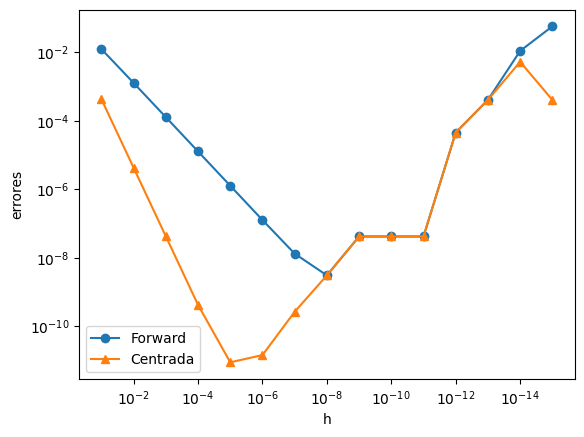

In [80]:
h_vals = [10**-n for n in range(1,16)]

errores_f = []
errores_c = []

for h in h_vals:

    df_val = forward(f,x0,h)
    dc_val = centrada(f,x0,h)

    err_df = np.abs(true_val - df_val)
    err_dc = np.abs(true_val - dc_val)

    errores_f.append(err_df)
    errores_c.append(err_dc)

plt.loglog(h_vals,errores_f,'o-',label="Forward")
plt.loglog(h_vals,errores_c,'^-',label="Centrada")

plt.xlabel("h")
plt.ylabel("errores")
plt.legend()

plt.gca().invert_xaxis()

plt.show()

